In [1]:
import pandas as pd
import numpy as np

C:\Users\SANTIAGO\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Para calculo del precio de referencia de la cosecha, se toma el promedio de los precios durante los meses de cosecha. Habria que solicitar al usuario en que precio de referencia tasa su seguro.

Precios locales en COP por cada 125 Kg.

In [3]:
precios_cop = pd.read_csv('../Data anual/Precio_COP.csv')
print("Precios locales")
print(precios_cop.info())
precios_cop['COP_125_Kg'] = precios_cop['COP_125_Kg'].astype(float)
precios_cop.head()

precios_cosecha_cop = precios_cop[precios_cop['Mes'].isin([9,10,11,12])].groupby('Year')[['COP_125_Kg']].mean()
precios_cosecha_cop.reset_index(inplace=True)
precios_cosecha_cop.head()

Precios locales
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8507 entries, 0 to 8506
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Fecha_orig  8507 non-null   object 
 1   Dia         8507 non-null   object 
 2   Mes         8507 non-null   int64  
 3   Year        8507 non-null   int64  
 4   COP_125_Kg  8507 non-null   float64
dtypes: float64(1), int64(2), object(2)
memory usage: 332.4+ KB
None


,Year,COP_125_Kg
0,2003,301.957992
1,2004,378.503074
2,2005,428.265369
3,2006,464.204918
4,2007,493.921107


Precios internacionales en centavos de dolar por libra.

In [4]:
precios = pd.read_csv('../Data anual/Precios.csv')
precios['Year'] = precios['Fecha'].astype(str).str[:4].astype(int)
precios['Mes'] = precios['Fecha'].astype(str).str[5:7]
print("Precios internacionales:")
print(precios.info())
precios_cosecha = precios[precios['Mes'].isin(['09','10','11','12'])].groupby('Year')[['Precio_indicador_compuesto_OIC_US_Cents', 'Nueva_York_US_Cents', 'Europa_US_Cents']].mean()
precios_cosecha.reset_index(inplace=True)
print("Precios de cosecha:")
precios_cosecha.tail(15)

Precios internacionales:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 6 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Mes                                      303 non-null    object 
 1   Fecha                                    303 non-null    object 
 2   Precio_indicador_compuesto_OIC_US_Cents  303 non-null    float64
 3   Nueva_York_US_Cents                      303 non-null    float64
 4   Europa_US_Cents                          303 non-null    float64
 5   Year                                     303 non-null    int32  
dtypes: float64(3), int32(1), object(2)
memory usage: 13.1+ KB
None
Precios de cosecha:


,Year,Precio_indicador_compuesto_OIC_US_Cents,Nueva_York_US_Cents,Europa_US_Cents
10,2011,197.4050,263.6300,263.1475
11,2012,141.5150,178.6225,174.5300
12,2013,106.6000,128.9525,132.5925
13,2014,161.8750,204.3200,209.9225
14,2015,115.3075,137.7600,140.9850
15,2016,139.6050,168.9325,169.5975
16,2017,118.9175,147.1275,143.1575
17,2018,104.8450,134.9250,131.6100
18,2019,104.9225,146.9750,137.5625
19,2020,111.6100,171.7825,152.4100


Precios anuales consolidados

In [ ]:
precios_cosecha = precios_cosecha.merge(precios_cosecha_cop, on='Year', how='inner')
precios_cosecha.head()

,Year,Precio_indicador_compuesto_OIC_US_Cents,Nueva_York_US_Cents,Europa_US_Cents,COP_125_Kg
0,2003,52.0175,67.8450,65.0950,301.957992
1,2004,67.0075,93.3325,88.4825,378.503074
2,2005,83.5300,107.0700,104.7025,428.265369
3,2006,100.7500,121.2525,119.0100,464.204918
4,2007,115.3675,135.7250,134.5875,493.921107


Carga de predicciones realizadas por el modelo.

In [6]:
predicciones = pd.read_excel('../Data anual/total_pred_final.xlsx')
print(predicciones.info())
predicciones.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  450 non-null    int64  
 1   Mpio                  450 non-null    object 
 2   Rendimiento           426 non-null    float64
 3   Rendimiento_Predicho  450 non-null    float64
 4   Error                 426 non-null    float64
 5   Abs_Error             426 non-null    float64
dtypes: float64(4), int64(1), object(1)
memory usage: 21.2+ KB
None


,Year,Mpio,Rendimiento,Rendimiento_Predicho,Error,Abs_Error
0,2007,MONIQUIRA_BOYACA,1.000000,0.939594,0.060406,0.060406
1,2008,MONIQUIRA_BOYACA,1.000000,0.919221,0.080779,0.080779
2,2009,MONIQUIRA_BOYACA,0.990000,0.931683,0.058317,0.058317
3,2010,MONIQUIRA_BOYACA,0.650000,0.819406,-0.169406,0.169406
4,2011,MONIQUIRA_BOYACA,0.668693,0.729976,-0.061283,0.061283
5,2012,MONIQUIRA_BOYACA,1.000000,0.896038,0.103962,0.103962
6,2013,MONIQUIRA_BOYACA,0.640093,0.683742,-0.043649,0.043649
7,2014,MONIQUIRA_BOYACA,0.692126,0.788489,-0.096363,0.096363
8,2015,MONIQUIRA_BOYACA,0.899531,1.066163,-0.166632,0.166632
9,2016,MONIQUIRA_BOYACA,0.930295,0.907958,0.022337,0.022337


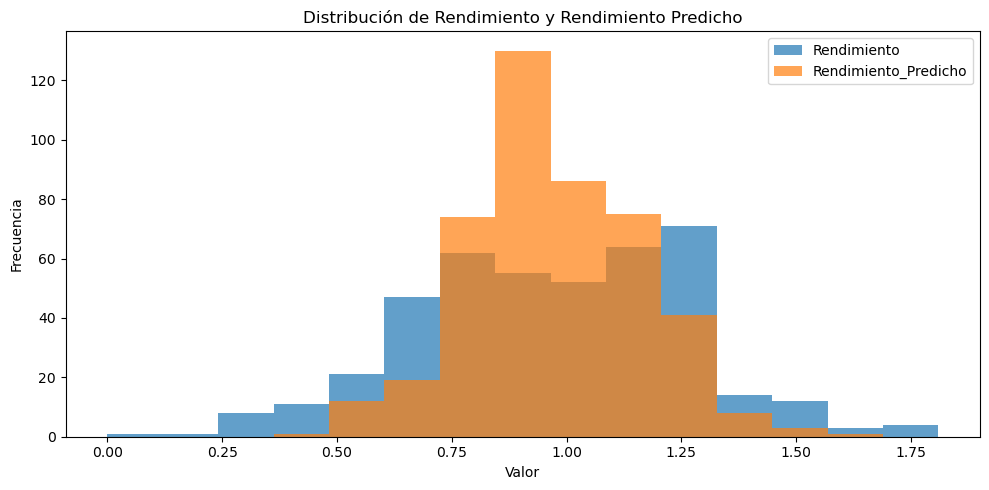

In [7]:
import matplotlib.pyplot as plt

ax = predicciones[['Rendimiento', 'Rendimiento_Predicho']].plot(
    kind='hist',
    bins=15,
    alpha=0.7,
    color=['tab:blue', 'tab:orange'],
    figsize=(10, 5)
)
ax.set_title('Distribución de Rendimiento y Rendimiento Predicho')
ax.set_xlabel('Valor')
ax.set_ylabel('Frecuencia')
plt.tight_layout()
plt.show()

Se calcula el corte del threshold: 1 desviacion estandar por debajo del promedio de rendimiento total, sin contar el ultimo año.

In [8]:
predicciones_mpio_min = predicciones[predicciones['Year'] != 2024].groupby('Mpio', as_index=False)['Rendimiento'].min()
predicciones_mpio_min.rename(columns={'Rendimiento': 'Rendimiento_min'}, inplace=True)
predicciones_mpio_max = predicciones[predicciones['Year'] != 2024].groupby('Mpio', as_index=False)['Rendimiento'].max()
predicciones_mpio_max.rename(columns={'Rendimiento': 'Rendimiento_max'}, inplace=True)

predicciones_mpio_avg = predicciones[predicciones['Year'] != 2024].groupby('Mpio', as_index=False)['Rendimiento'].mean()
predicciones_mpio_avg.rename(columns={'Rendimiento': 'Rendimiento_avg'}, inplace=True)
predicciones_mpio_avg['Std'] = predicciones.groupby('Mpio')['Rendimiento'].std().values
predicciones_mpio_avg['Std_thresh_1'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']
predicciones_mpio_avg['Std_thresh_2'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']*2
predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_min, on='Mpio', how='left')
predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_max, on='Mpio', how='left')
predicciones_mpio_avg

,Mpio,Rendimiento_avg,Std,Std_thresh_1,Std_thresh_2,Rendimiento_min,Rendimiento_max
0,AGUADA_SANTANDER,0.973456,0.440875,0.532580,0.091705,0.300000,1.723765
1,BARBOSA_SANTANDER,1.107032,0.222439,0.884593,0.662153,0.722822,1.500000
2,CHARALA_SANTANDER,0.999516,0.225404,0.774112,0.548708,0.672147,1.323013
3,CHIPATA_SANTANDER,0.947795,0.365098,0.582697,0.217599,0.317201,1.321727
4,CONFINES_SANTANDER,0.889573,0.268010,0.621562,0.353552,0.553333,1.348536
5,CURITI_SANTANDER,0.984168,0.319372,0.664796,0.345423,0.600000,1.510001
6,EL SOCORRO_SANTANDER,1.000569,0.215656,0.784914,0.569258,0.704630,1.346927
7,GUADALUPE_SANTANDER,0.934475,0.285402,0.649072,0.363670,0.620878,1.321728
8,GUAPOTA_SANTANDER,1.009443,0.258427,0.751016,0.492589,0.600000,1.435897
9,GUEPSA_SANTANDER,1.010127,0.276349,0.733778,0.457430,0.413052,1.551388


## Función de cálculo
Se activa la clausula de aseguramiento, si la estimación del rendimiento se encuentra debajo del rendimiento promedio del municipio, menos una desviación estándar del rendimiento.
El valor máximo de aseguramiento es equivalente al mínimo hisotico multiplicado por el valor actual local en COP.

El % de cobertura es equivalente al valor de la diferencia entre el umbral de aseguarmiento y el valor estimado de la producción.

In [17]:
#Función de carga de precios
def carga_precios():
    #Precios en COP
    precios_cop = pd.read_csv('../Data anual/Precio_COP.csv')
    precios_cop['COP_125_Kg'] = precios_cop['COP_125_Kg'].astype(float)
    precios_cosecha_cop = precios_cop[precios_cop['Mes'].isin([9,10,11,12])].groupby('Year')[['COP_125_Kg']].mean()
    precios_cosecha_cop.reset_index(inplace=True)

    #Precios internacionales
    precios = pd.read_csv('../Data anual/Precios.csv')
    precios['Year'] = precios['Fecha'].astype(str).str[:4].astype(int)
    precios['Mes'] = precios['Fecha'].astype(str).str[5:7]
    precios_cosecha = precios[precios['Mes'].isin(['09','10','11','12'])].groupby('Year')[['Precio_indicador_compuesto_OIC_US_Cents', 'Nueva_York_US_Cents', 'Europa_US_Cents']].mean()
    precios_cosecha.reset_index(inplace=True)

    #Precios consolidados
    precios_cosecha = precios_cosecha.merge(precios_cosecha_cop, on='Year', how='inner')
    return precios_cosecha

def carga_predicciones(año):
    predicciones = pd.read_excel('../Data anual/total_pred_final.xlsx')

    predicciones_mpio_min = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].min()
    predicciones_mpio_min.rename(columns={'Rendimiento': 'Rendimiento_min'}, inplace=True)
    predicciones_mpio_max = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].max()
    predicciones_mpio_max.rename(columns={'Rendimiento': 'Rendimiento_max'}, inplace=True)

    predicciones_mpio_avg = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].mean()
    predicciones_mpio_avg.rename(columns={'Rendimiento': 'Rendimiento_avg'}, inplace=True)
    predicciones_mpio_avg['Std'] = predicciones.groupby('Mpio')['Rendimiento'].std().values
    predicciones_mpio_avg['Std_thresh_1'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']
    predicciones_mpio_avg['Std_thresh_2'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']*2
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_min, on='Mpio', how='left')
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_max, on='Mpio', how='left')    

    return predicciones, predicciones_mpio_avg   

def calcula_aseguramiento(hecatareas_seguro,Municipio_asegurado,año):
    #Carga información de precios
    precios_cosecha = carga_precios()

    #Carga información de predicciones
    predicciones, predicciones_mpio_avg   = carga_predicciones(año=año)

    #Extrayendo calculos de la preducción para el municipio asegurado
    pred_actual = predicciones[(predicciones['Mpio'] == Municipio_asegurado) & (predicciones['Year'] ==año)]
    rendimiento_pred = round(pred_actual['Rendimiento_Predicho'].values[0],4)

    #Extrayendo el umbral de la desviación estándar para el municipio asegurado
    pred_mpio_avg = predicciones_mpio_avg[predicciones_mpio_avg['Mpio'] == Municipio_asegurado]
    pred_mpio_thresh = round(pred_mpio_avg['Std_thresh_1'].values[0],4)
    pred_mpio_min = round(pred_mpio_avg['Rendimiento_min'].values[0],4)

    #Informacion de precios
    precios_cosecha_actual = precios_cosecha[precios_cosecha['Year'] == pred_actual['Year'].values[0]]

    #Calculando la cosecha estimada 

    #En la predicción
    produccion_estimada = round(rendimiento_pred*hecatareas_seguro,4) * 1000 #Se pasa la producción a kg
    produccion_estimada_saco = round(produccion_estimada/125,2) #Se pasa la producción a sacos para poder convertir a COP

    #En el umbral de la desviación estándar
    produccion_estimada_thershold = round(pred_mpio_thresh*hecatareas_seguro,4) * 1000 #Se pasa la producción a kg
    produccion_estimada_thershold_saco = round(produccion_estimada_thershold/125,2) #Se pasa la producción a sacos para poder convertir a COP

    #En el mínimo histórico
    minima_produccion = round(pred_mpio_min*hecatareas_seguro,4) * 1000 #Se pasa la producción a kg
    minima_produccion_saco = round(minima_produccion/125,2) #Se pasa la producción a sacos para poder convertir a COP

    #Costos de la cosecha
    costo_cosecha = round(produccion_estimada_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]
    costo_cosecha_thresh = round(produccion_estimada_thershold_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]
    costo_cosecha_min = round(minima_produccion_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]

    #Valor asegurado
    valor_asegurado = costo_cosecha_thresh - costo_cosecha
    #Valor máximo a indemnizar
    valor_max_indemnizar = costo_cosecha_thresh - costo_cosecha_min

    if rendimiento_pred < pred_mpio_thresh:
        if rendimiento_pred <= pred_mpio_min:
            print(f"Alerta: El rendimiento predicho para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por debajo del mínimo histórico de {pred_mpio_min} kg/ha.") 
            print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos / {round(produccion_estimada,2)} kg.")
            print(f"\nEs elegible para recibir el equivalente a la maxima compensacion: {round(valor_max_indemnizar)} COP.")

        print(f"Alerta: El rendimiento predicho para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por debajo del umbral de {pred_mpio_thresh} kg/ha.") 
        print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos / {round(produccion_estimada,2)} kg.")
        print(f"\nEs elegible para recibir apoyo equivalente a: {round(valor_asegurado)} COP.")
    else:
        print(f"La producción predicha para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por encima o igual al umbral de {pred_mpio_thresh} kg/ha.") 
        print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos / {round(produccion_estimada,2)} kg.")
        print(f"\nNo es elegible para recibir apoyo.")

    return rendimiento_pred, costo_cosecha, valor_asegurado, valor_max_indemnizar

Ejemplos de uso

In [147]:
rendimiento_pred, costo_cosecha, valor_asegurado, valor_max_indemnizar = calcula_aseguramiento(hecatareas_seguro=5,Municipio_asegurado ='SAN GIL_SANTANDER' ,año=2024)

La producción predicha para SAN GIL_SANTANDER es de 0.9264 kg/ha, lo cual está por encima o igual al umbral de 0.57 kg/ha.
La cosecha se estima en un valor de 88211002 COP, con una producción estimada de 37.06 sacos / 4632.0 kg.

No es elegible para recibir apoyo.


In [148]:
rendimiento_pred, costo_cosecha, valor_asegurado, valor_max_indemnizar = calcula_aseguramiento(hecatareas_seguro=3.2,Municipio_asegurado ='CHARALA_SANTANDER' ,año=2024)

La producción predicha para CHARALA_SANTANDER es de 0.9697 kg/ha, lo cual está por encima o igual al umbral de 0.7741 kg/ha.
La cosecha se estima en un valor de 59077093 COP, con una producción estimada de 24.82 sacos / 3103.0 kg.

No es elegible para recibir apoyo.


## Nueva funcion con rangos de confinza
Se modifican las funciones para reportar ahora los intervalos de confianza para las estimaciones de:
- Rendimientos
- Cosecha estimada 
- Costo de cosecha estimada

Los intervalos se calculan estimando el promedio de los errores positivos y negativos para cada municipio y luego adicionandolos al valor estimado.

La función retorna ahora un diccionario con los valores predichos y los intervalos de confianza para cada tipo de valor.


In [10]:
#Función de carga de precios
def carga_precios():
    #Precios en COP
    precios_cop = pd.read_csv('../Data anual/Precio_COP.csv')
    precios_cop['COP_125_Kg'] = precios_cop['COP_125_Kg'].astype(float)
    precios_cosecha_cop = precios_cop[precios_cop['Mes'].isin([9,10,11,12])].groupby('Year')[['COP_125_Kg']].mean()
    precios_cosecha_cop.reset_index(inplace=True)

    #Precios internacionales
    precios = pd.read_csv('../Data anual/Precios.csv')
    precios['Year'] = precios['Fecha'].astype(str).str[:4].astype(int)
    precios['Mes'] = precios['Fecha'].astype(str).str[5:7]
    precios_cosecha = precios[precios['Mes'].isin(['09','10','11','12'])].groupby('Year')[['Precio_indicador_compuesto_OIC_US_Cents', 'Nueva_York_US_Cents', 'Europa_US_Cents']].mean()
    precios_cosecha.reset_index(inplace=True)

    #Precios consolidados
    precios_cosecha = precios_cosecha.merge(precios_cosecha_cop, on='Year', how='inner')
    return precios_cosecha

def carga_predicciones_intervalo(año):
    predicciones = pd.read_excel('../Data anual/total_pred_final.xlsx')

    predicciones_mpio_min = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].min()
    predicciones_mpio_min.rename(columns={'Rendimiento': 'Rendimiento_min'}, inplace=True)
    predicciones_mpio_max = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].max()
    predicciones_mpio_max.rename(columns={'Rendimiento': 'Rendimiento_max'}, inplace=True)

    predicciones_mpio_avg = predicciones[predicciones['Year'] != año].groupby('Mpio', as_index=False)['Rendimiento'].mean()
    predicciones_mpio_avg.rename(columns={'Rendimiento': 'Rendimiento_avg'}, inplace=True)
    predicciones_mpio_avg['Std'] = predicciones.groupby('Mpio')['Rendimiento'].std().values
    predicciones_mpio_avg['Std_thresh_1'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']
    predicciones_mpio_avg['Std_thresh_2'] = predicciones_mpio_avg['Rendimiento_avg'] - predicciones_mpio_avg['Std']*2

    #Se calcula el promedio del errorpositivo y negativo para cada municipio para poder calcular un intervalo de confianza para la predicción
    
    #Errores positivos
    predicciones_mpio_err_pos = predicciones[(predicciones['Year']<=año) & (predicciones['Error']>0)].groupby('Mpio')[['Error']].mean()
    predicciones_mpio_err_pos.rename(columns={'Error': 'Error_positivo'}, inplace=True)
    #Errores negativos
    predicciones_mpio_err_neg = predicciones[(predicciones['Year']<=año) & (predicciones['Error']<0)].groupby('Mpio')[['Error']].mean()
    predicciones_mpio_err_neg.rename(columns={'Error': 'Error_negativo'}, inplace=True)

    #Join de informacion 
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_min, on='Mpio', how='left')
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_max, on='Mpio', how='left')    
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_err_pos, on='Mpio', how='left')
    predicciones_mpio_avg = predicciones_mpio_avg.merge(predicciones_mpio_err_neg, on='Mpio', how='left')

    return predicciones, predicciones_mpio_avg  

def calcula_aseguramiento_intervalo(hecatareas_seguro,Municipio_asegurado,año):
    #Carga información de precios
    precios_cosecha = carga_precios()

    #Carga información de predicciones
    predicciones, predicciones_mpio_avg   = carga_predicciones_intervalo(año=año)

    #Extrayendo calculos de la preducción para el municipio asegurado
    pred_actual = predicciones[(predicciones['Mpio'] == Municipio_asegurado) & (predicciones['Year'] ==año)]
    rendimiento_pred = round(pred_actual['Rendimiento_Predicho'].values[0],4)

    #Extrayendo el umbral de aseguramiento: la desviación estándar para el municipio asegurado
    pred_mpio_avg = predicciones_mpio_avg[predicciones_mpio_avg['Mpio'] == Municipio_asegurado]
    pred_mpio_thresh = round(pred_mpio_avg['Std_thresh_1'].values[0],4)
    pred_mpio_min = round(pred_mpio_avg['Rendimiento_min'].values[0],4)

    #Calculando intervalo de confianza para la predicción
    pred_mpio_error_neg = round(pred_mpio_avg['Error_negativo'].values[0],4)
    pred_mpio_error_pos = round(pred_mpio_avg['Error_positivo'].values[0],4)

    rendimiento_inf = rendimiento_pred + pred_mpio_error_neg
    rendimiento_sup = rendimiento_pred + pred_mpio_error_pos

    #Informacion de precios
    precios_cosecha_actual = precios_cosecha[precios_cosecha['Year'] == pred_actual['Year'].values[0]]

    #Calculando la cosecha estimada 
    #En la predicción
    produccion_estimada = round(rendimiento_pred*hecatareas_seguro,1) * 1000 #Se pasa la producción a kg
    produccion_estimada_saco = round((produccion_estimada/125)) #Se pasa la producción a sacos para poder convertir a COP

    #En el intervalo de confianzaz
    produccion_estimada_inf = round((rendimiento_inf*hecatareas_seguro),1) * 1000 #Se pasa la producción a kg
    produccion_estimada_inf_saco = round((produccion_estimada_inf/125)) #Se pasa la producción a sacos para poder convertir a COP
    produccion_estimada_sup = round((rendimiento_sup*hecatareas_seguro),1) * 1000 #Se pasa la producción a kg
    produccion_estimada_sup_saco = round((produccion_estimada_sup/125)) #Se pasa la producción a sacos para poder convertir a COP


    #En el umbral de aseguramiento: la desviación estándar
    produccion_estimada_thershold = round(pred_mpio_thresh*hecatareas_seguro,4) * 1000 #Se pasa la producción a kg
    produccion_estimada_thershold_saco = round(produccion_estimada_thershold/125,4) #Se pasa la producción a sacos para poder convertir a COP
    #En el mínimo histórico
    minima_produccion = round(pred_mpio_min*hecatareas_seguro,4) * 1000 #Se pasa la producción a kg
    minima_produccion_saco = round(minima_produccion/125,4) #Se pasa la producción a sacos para poder convertir a COP

    #Costos de la cosecha
    costo_cosecha = round(produccion_estimada_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]
    costo_cosecha_lim_sup = round(produccion_estimada_sup_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]
    costo_cosecha_lim_inf = round(produccion_estimada_inf_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]

    costo_cosecha_thresh = round(produccion_estimada_thershold_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]
    costo_cosecha_min = round(minima_produccion_saco*1000)*precios_cosecha_actual['COP_125_Kg'].values[0]

    #Valor asegurado
    valor_asegurado = costo_cosecha_thresh - costo_cosecha
    #Valor máximo a indemnizar
    valor_max_indemnizar = costo_cosecha_thresh - costo_cosecha_min


    if rendimiento_pred < pred_mpio_thresh:
        if rendimiento_pred <= pred_mpio_min:
                print(f"Alerta: El rendimiento predicho para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por debajo del mínimo histórico de {pred_mpio_min} kg/ha.") 
                print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos | {round(produccion_estimada,2)} kg.")
                print(f"Es elegible para recibir el equivalente a la maxima compensacion: {round(valor_max_indemnizar)} COP.")

        print(f"Alerta: El rendimiento predicho para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por debajo del umbral de aseguramiento: {pred_mpio_thresh} kg/ha.") 
        print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos | {round(produccion_estimada,2)} kg.")
        print(f"Es elegible para recibir apoyo equivalente a: {round(valor_asegurado)} COP.")
    else:
        print(f"El rendimiento predicho para {Municipio_asegurado} es de {rendimiento_pred} kg/ha, lo cual está por encima o igual al umbral de aseguramiento: {pred_mpio_thresh} kg/ha.") 
        print(f"La cosecha se estima en un valor de {round(costo_cosecha)} COP, con una producción estimada de {round(produccion_estimada_saco,2)} sacos | {round(produccion_estimada,2)} kg.")
        print(f"No es elegible para recibir apoyo.")

    print("\nInformación adicional:")
    print(f"\nRendimiento predicho: {rendimiento_pred} ton/ha")
    print(f"    Intervalo de confianza: [{rendimiento_inf}, {rendimiento_sup}] ton/ha")
    print(f"\nProduccion predicha: {produccion_estimada} kg | {produccion_estimada_saco} sacos")
    print(f"    Intervalo de confianza: [{produccion_estimada_inf}, {produccion_estimada_sup}] kg | [{produccion_estimada_inf_saco}, {produccion_estimada_sup_saco}] sacos")
    print(f"\nCosto predicho: {round(costo_cosecha)} COP")
    print(f"    Intervalo de confianza: [{round(costo_cosecha_lim_inf)}, {round(costo_cosecha_lim_sup)}] COP")

    resultados = {
        'Rendimiento_predicho': rendimiento_pred,
        'Rendimiento_inf': rendimiento_inf,
        'Rendimiento_sup': rendimiento_sup,
        'Cosecha_estimada': produccion_estimada,
        'Cosecha_estimada_inf': produccion_estimada_inf,
        'Cosecha_estimada_sup': produccion_estimada_sup,
        'Costo_cosecha': costo_cosecha,
        'costo_cosecha_lim_inf': costo_cosecha_lim_inf,
        'costo_cosecha_lim_sup': costo_cosecha_lim_sup,
        'Valor_asegurado': valor_asegurado,
        'Valor_max_indemnizar': valor_max_indemnizar
    }

    return resultados

In [11]:
resultados = calcula_aseguramiento_intervalo(hecatareas_seguro=3.2,Municipio_asegurado ='CHARALA_SANTANDER' ,año=2024)

El rendimiento predicho para CHARALA_SANTANDER es de 0.9697 kg/ha, lo cual está por encima o igual al umbral de aseguramiento: 0.7741 kg/ha.
La cosecha se estima en un valor de 59505533 COP, con una producción estimada de 25 sacos | 3100.0 kg.
No es elegible para recibir apoyo.

Información adicional:

Rendimiento predicho: 0.9697 ton/ha
    Intervalo de confianza: [0.8961, 1.0574] ton/ha

Produccion predicha: 3100.0 kg | 25 sacos
    Intervalo de confianza: [2900.0, 3400.0] kg | [23, 27] sacos

Costo predicho: 59505533 COP
    Intervalo de confianza: [54745090, 64265975] COP


In [12]:
resultados

{'Rendimiento_predicho': 0.9697,
 'Rendimiento_inf': 0.8961,
 'Rendimiento_sup': 1.0574,
 'Cosecha_estimada': 3100.0,
 'Cosecha_estimada_inf': 2900.0,
 'Cosecha_estimada_sup': 3400.0,
 'Costo_cosecha': 59505532.78688525,
 'costo_cosecha_lim_inf': 54745090.16393443,
 'costo_cosecha_lim_sup': 64265975.40983607,
 'Valor_asegurado': -12336687.057377048,
 'Valor_max_indemnizar': 6214757.8442622945}

### Validaciones por año

#### 2023

In [ ]:
res = {}
año = 2023

for mpio in list(predicciones[predicciones['Year'] == año].Mpio.unique()):
    print(mpio)
    resultados = calcula_aseguramiento_intervalo(hecatareas_seguro=3.2,Municipio_asegurado =mpio , año=año)
    res[mpio] = resultados['Valor_asegurado']

res_df_ini = pd.DataFrame.from_dict(res, orient='index', columns=['Valor_asegurado'])
res_df_ini.reset_index(inplace=True)

MONIQUIRA_BOYACA
El rendimiento predicho para MONIQUIRA_BOYACA es de 0.9014 kg/ha, lo cual está por encima o igual al umbral de aseguramiento: 0.7365 kg/ha.
La cosecha se estima en un valor de 31867443 COP, con una producción estimada de 23 sacos | 2900.0 kg.
No es elegible para recibir apoyo.

Información adicional:

Rendimiento predicho: 0.9014 ton/ha
    Intervalo de confianza: [0.8176, 0.9751] ton/ha

Produccion predicha: 2900.0 kg | 23 sacos
    Intervalo de confianza: [2600.0, 3100.0] kg | [21, 25] sacos

Costo predicho: 31867443 COP
    Intervalo de confianza: [29096361, 34638525] COP
SAN JOSE DE PARE_BOYACA
El rendimiento predicho para SAN JOSE DE PARE_BOYACA es de 1.0259 kg/ha, lo cual está por encima o igual al umbral de aseguramiento: 0.7295 kg/ha.
La cosecha se estima en un valor de 36024066 COP, con una producción estimada de 26 sacos | 3300.0 kg.
No es elegible para recibir apoyo.

Información adicional:

Rendimiento predicho: 1.0259 ton/ha
    Intervalo de confianza: [0.

,index,Valor_asegurado
0,MONIQUIRA_BOYACA,-5.744453e+06
1,SAN JOSE DE PARE_BOYACA,-1.014909e+07
2,SANTANA_BOYACA,-8.562643e+06
3,TOGUI_BOYACA,-8.662402e+06
4,AGUADA_SANTANDER,-2.224902e+07
5,BARBOSA_SANTANDER,1.143071e+06
6,CHARALA_SANTANDER,-9.438305e+06
7,CHIPATA_SANTANDER,-1.511764e+07
8,CONFINES_SANTANDER,-1.502481e+07
9,CURITI_SANTANDER,-1.330812e+07


In [14]:
res_df_ini

,index,Valor_asegurado
0,MONIQUIRA_BOYACA,-5.744453e+06
1,SAN JOSE DE PARE_BOYACA,-1.014909e+07
2,SANTANA_BOYACA,-8.562643e+06
3,TOGUI_BOYACA,-8.662402e+06
4,AGUADA_SANTANDER,-2.224902e+07
5,BARBOSA_SANTANDER,1.143071e+06
6,CHARALA_SANTANDER,-9.438305e+06
7,CHIPATA_SANTANDER,-1.511764e+07
8,CONFINES_SANTANDER,-1.502481e+07
9,CURITI_SANTANDER,-1.330812e+07


#### 2024

In [15]:

res = {}
año = 2024

for mpio in list(predicciones[predicciones['Year'] == año].Mpio.unique()):
    print(mpio)
    resultados = calcula_aseguramiento_intervalo(hecatareas_seguro=3.2,Municipio_asegurado =mpio , año=año)
    res[mpio] = resultados['Valor_asegurado']

res_df_ini = pd.DataFrame.from_dict(res, orient='index', columns=['Valor_asegurado'])
res_df_ini.reset_index(inplace=True)


MONIQUIRA_BOYACA
El rendimiento predicho para MONIQUIRA_BOYACA es de 0.8364 kg/ha, lo cual está por encima o igual al umbral de aseguramiento: 0.7261 kg/ha.
La cosecha se estima en un valor de 52364869 COP, con una producción estimada de 22 sacos | 2700.0 kg.
No es elegible para recibir apoyo.

Información adicional:

Rendimiento predicho: 0.8364 ton/ha
    Intervalo de confianza: [0.7526, 0.9139] ton/ha

Produccion predicha: 2700.0 kg | 22 sacos
    Intervalo de confianza: [2400.0, 2900.0] kg | [19, 23] sacos

Costo predicho: 52364869 COP
    Intervalo de confianza: [45224205, 54745090] COP
SAN JOSE DE PARE_BOYACA
El rendimiento predicho para SAN JOSE DE PARE_BOYACA es de 0.9045 kg/ha, lo cual está por encima o igual al umbral de aseguramiento: 0.7558 kg/ha.
La cosecha se estima en un valor de 54745090 COP, con una producción estimada de 23 sacos | 2900.0 kg.
No es elegible para recibir apoyo.

Información adicional:

Rendimiento predicho: 0.9045 ton/ha
    Intervalo de confianza: [0.

In [16]:
res_df_ini

,index,Valor_asegurado
0,MONIQUIRA_BOYACA,-8.121315e+06
1,SAN JOSE DE PARE_BOYACA,-8.690188e+06
2,SANTANA_BOYACA,-2.694649e+07
3,TOGUI_BOYACA,-1.108469e+07
4,AGUADA_SANTANDER,-2.943382e+07
5,BARBOSA_SANTANDER,1.537623e+06
6,CHARALA_SANTANDER,-1.233669e+07
7,CHIPATA_SANTANDER,-2.161955e+07
8,CONFINES_SANTANDER,-1.686863e+07
9,CURITI_SANTANDER,-2.375699e+07


Luego de validar en el servicio, el 100% de los casos es igual.